In [1]:
#Carga de Datos
import os
import pandas as pd

BASE_PATH = os.path.join(os.getcwd(), '..', 'data', 'processed')

df_model = pd.read_csv(os.path.join(BASE_PATH, 'df_model.csv'))
recomendaciones = pd.read_csv(os.path.join(BASE_PATH, 'recomendaciones_modelo.csv'))

print(df_model.shape)
print(recomendaciones.shape)

display(df_model.head())
display(recomendaciones.head())

(112915, 18)
(42, 5)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status,product_category_name_english,grupo_categoria,review_score,year,month,day_of_week,hour,time_of_day
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,cool_stuff,Recreación,5.0,2017,9,2,8,morning
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,pet_shop,Recreación,4.0,2017,4,2,10,morning
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,furniture_decor,Hogar,5.0,2018,1,6,14,afternoon
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,perfumery,Cuidado Personal,4.0,2018,8,2,10,morning
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered,garden_tools,Hogar,5.0,2017,2,5,13,afternoon


,grupo_a,grupo_b,frecuencia,ticket_grupo_b,score
0,Alimentos,Cuidado Personal,6,126.306038,0.141264
1,Alimentos,Recreación,6,126.719138,0.135535
2,Alimentos,Automotor,1,139.806284,0.130828
3,Alimentos,Hogar,5,106.155947,0.071586
4,Alimentos,Tecnología,2,110.216416,0.058944


In [2]:
print(df_model.columns)
print(recomendaciones.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_purchase_timestamp', 'order_status',
       'product_category_name_english', 'grupo_categoria', 'review_score',
       'year', 'month', 'day_of_week', 'hour', 'time_of_day'],
      dtype='object')
Index(['grupo_a', 'grupo_b', 'frecuencia', 'ticket_grupo_b', 'score'], dtype='object')


In [3]:
#que otros grupos aparecen en la misma orden
ordenes = (
    df_model.groupby("order_id")["grupo_categoria"]
    .apply(lambda x: list(set(x)))
    .reset_index(name="grupos")
)

ordenes.head()

,order_id,grupos
0,00010242fe8c5a6d1ba2dd792cb16214,[Recreación]
1,00018f77f2f0320c557190d7a144bdd3,[Recreación]
2,000229ec398224ef6ca0657da4fc703e,[Hogar]
3,00024acbcdf0a6daa1e931b038114c75,[Cuidado Personal]
4,00042b26cf59d7ce69dfabb4e55b4fd9,[Hogar]


In [4]:
#evaluacion del modelo: para cada orden, se toma un grupo como origen y se evalua si los otros grupos recomendados aparecen en la misma orden
rows = []

for _, row in ordenes.iterrows():
    grupos = row["grupos"]
    
    if len(grupos) > 1:
        for g in grupos:
            reales = [x for x in grupos if x != g]
            
            rows.append({
                "order_id": row["order_id"],
                "grupo_origen": g,
                "reales": reales
            })

eval_df = pd.DataFrame(rows)
eval_df.head()

,order_id,grupo_origen,reales
0,002f98c0f7efd42638ed6100ca699b42,Recreación,[Tecnología]
1,002f98c0f7efd42638ed6100ca699b42,Tecnología,[Recreación]
2,014405982914c2cde2796ddcf0b8703d,Recreación,[Cuidado Personal]
3,014405982914c2cde2796ddcf0b8703d,Cuidado Personal,[Recreación]
4,01cce1175ac3c4a450e3a0f856d02734,Viaje y accesorios,[Hogar]


In [6]:
print(recomendaciones.columns.tolist())
recomendaciones.head()

['grupo_a', 'grupo_b', 'frecuencia', 'ticket_grupo_b', 'score']


,grupo_a,grupo_b,frecuencia,ticket_grupo_b,score
0,Alimentos,Cuidado Personal,6,126.306038,0.141264
1,Alimentos,Recreación,6,126.719138,0.135535
2,Alimentos,Automotor,1,139.806284,0.130828
3,Alimentos,Hogar,5,106.155947,0.071586
4,Alimentos,Tecnología,2,110.216416,0.058944


In [7]:
recs_dict = (
    recomendaciones
    .sort_values("score", ascending=False)
    .groupby("grupo_a")["grupo_b"]
    .apply(list)
    .to_dict()
)

In [8]:
col_origen = "grupo_a"
col_reco = "grupo_b"

In [9]:
#baseline (popularidad)
top_grupos = df_model["grupo_categoria"].value_counts().index.tolist()

def baseline(grupo, k=5):
    return [g for g in top_grupos if g != grupo][:k]

In [10]:
#Metricas
def precision_at_k(reales, predichos, k=5):
    pred_k = predichos[:k]
    return len(set(pred_k) & set(reales)) / k

def recall_at_k(reales, predichos, k=5):
    if len(reales) == 0:
        return 0
    pred_k = predichos[:k]
    return len(set(pred_k) & set(reales)) / len(reales)

In [11]:
K = 5

eval_df["pred_modelo"] = eval_df["grupo_origen"].apply(
    lambda g: recs_dict.get(g, [])[:K]
)

eval_df["pred_baseline"] = eval_df["grupo_origen"].apply(
    lambda g: baseline(g, K)
)

eval_df["precision_modelo"] = eval_df.apply(
    lambda r: precision_at_k(r["reales"], r["pred_modelo"], K), axis=1
)

eval_df["precision_baseline"] = eval_df.apply(
    lambda r: precision_at_k(r["reales"], r["pred_baseline"], K), axis=1
)

eval_df["recall_modelo"] = eval_df.apply(
    lambda r: recall_at_k(r["reales"], r["pred_modelo"], K), axis=1
)

eval_df["recall_baseline"] = eval_df.apply(
    lambda r: recall_at_k(r["reales"], r["pred_baseline"], K), axis=1
)

In [12]:
#Resultados
print("Precision@K:")
print("Baseline:", eval_df["precision_baseline"].mean())
print("Modelo:", eval_df["precision_modelo"].mean())

print("\nRecall@K:")
print("Baseline:", eval_df["recall_baseline"].mean())
print("Modelo:", eval_df["recall_modelo"].mean())

Precision@K:
Baseline: 0.15647442872687703
Modelo: 0.07986942328618062

Recall@K:
Baseline: 0.7600652883569097
Modelo: 0.3900979325353645


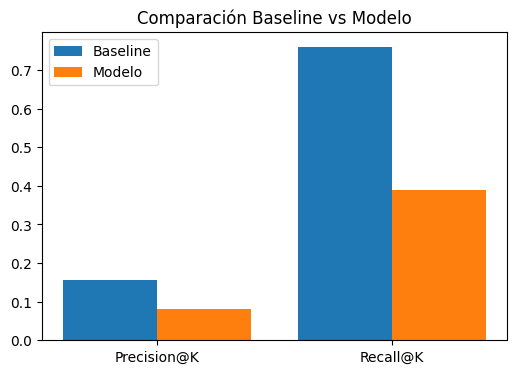

In [13]:
import matplotlib.pyplot as plt

labels = ["Precision@K", "Recall@K"]
baseline_vals = [
    eval_df["precision_baseline"].mean(),
    eval_df["recall_baseline"].mean()
]

modelo_vals = [
    eval_df["precision_modelo"].mean(),
    eval_df["recall_modelo"].mean()
]

x = range(len(labels))

plt.figure(figsize=(6,4))
plt.bar(x, baseline_vals, width=0.4, label="Baseline")
plt.bar([i + 0.4 for i in x], modelo_vals, width=0.4, label="Modelo")

plt.xticks([i + 0.2 for i in x], labels)
plt.title("Comparación Baseline vs Modelo")
plt.legend()
plt.show()

In [17]:
#conclusion
if eval_df["precision_modelo"].mean() > eval_df["precision_baseline"].mean():
    print("El modelo supera al baseline en Precision@K")
else:
    print("El modelo no supera al baseline en Precision@K, pero introduce recomendaciones más estratégicas basadas en co-ocurrencia y valor.")

El modelo no supera al baseline en Precision@K, pero introduce recomendaciones más estratégicas basadas en co-ocurrencia y valor.
